In [2]:
import json, hashlib
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# Paths
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CG_DIR  = ROOT / "data" / "raw" / "Comment_Generation"
DQE_DIR = ROOT / "data" / "raw" / "Diff_Quality_Estimation"

train_file = CG_DIR / "msg-train.jsonl"
valid_file = CG_DIR / "msg-valid.jsonl"
test_file  = CG_DIR / "msg-test.jsonl"

def h(text):
    return hashlib.md5(text.encode('utf-8', errors='ignore')).hexdigest()

# Check
for name, p in [("train",train_file),("valid",valid_file),("test",test_file)]:
    print(f"{name:6s}: exists={p.exists()}")

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
print("\nSetup done")

train : exists=True
valid : exists=True
test  : exists=True

Setup done


In [3]:

plt.rcParams.update({
    'figure.figsize': (11, 5),
    'font.size': 13,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})


In [4]:
def load_jsonl(path):
    rows = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

print("Loading files")
train = load_jsonl(train_file)
valid = load_jsonl(valid_file)
test  = load_jsonl(test_file)

print(f"train : {len(train):,} rows")
print(f"valid : {len(valid):,} rows")
print(f"test  : {len(test):,} rows")
print(f"TOTAL : {len(train)+len(valid)+len(test):,} rows")

Loading files
train : 117,739 rows
valid : 10,319 rows
test  : 10,169 rows
TOTAL : 138,227 rows


In [ ]:
cls_oldf_to_lang = {}
for fname in ["cls-train-chunk-1.jsonl", "cls-test.jsonl", "cls-valid.jsonl"]:
    fp = DQE_DIR / fname
    if fp.exists():
        with open(fp, encoding='utf-8') as f:
            for line in f:
                s = json.loads(line)
                if s.get('oldf') and 'lang' in s:
                    cls_oldf_to_lang[h(s['oldf'])] = s['lang']

print(f"Verified language map: {len(cls_oldf_to_lang):,} files")

for r in train:
    r['lang_verified'] = cls_oldf_to_lang.get(h(r.get('oldf','')), None)

tagged = sum(1 for r in train if r['lang_verified'])
print(f"Train rows tagged with verified lang: {tagged:,} / {len(train):,}")

Verified language map: 56,477 files
Train rows tagged with verified lang: 11,405 / 117,739


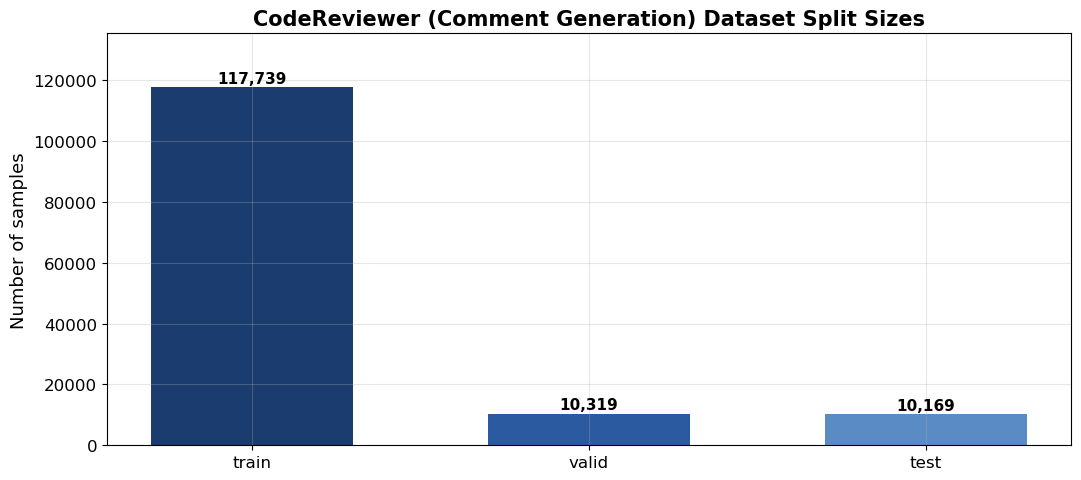


Total samples: 138,227
  train :  117,739  (85.2%)
  valid :   10,319  (7.5%)
  test  :   10,169  (7.4%)


In [5]:

sizes = {'train': len(train), 'valid': len(valid), 'test': len(test)}

fig, ax = plt.subplots()
bars = ax.bar(sizes.keys(), sizes.values(),
              color=['#1a3c6e', '#2c5aa0', '#5a8bc4'], width=0.6)


for bar, val in zip(bars, sizes.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1500,
            f'{val:,}', ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Number of samples')
ax.set_title('CodeReviewer (Comment Generation) Dataset Split Sizes')
ax.set_ylim(0, max(sizes.values()) * 1.15)
plt.tight_layout()
fig.savefig('fig_sizes.png', dpi=150, bbox_inches='tight')
plt.show()


total = sum(sizes.values())
print(f"\nTotal samples: {total:,}")
for k, v in sizes.items():
    print(f"  {k:6s}: {v:>8,}  ({v/total*100:.1f}%)")

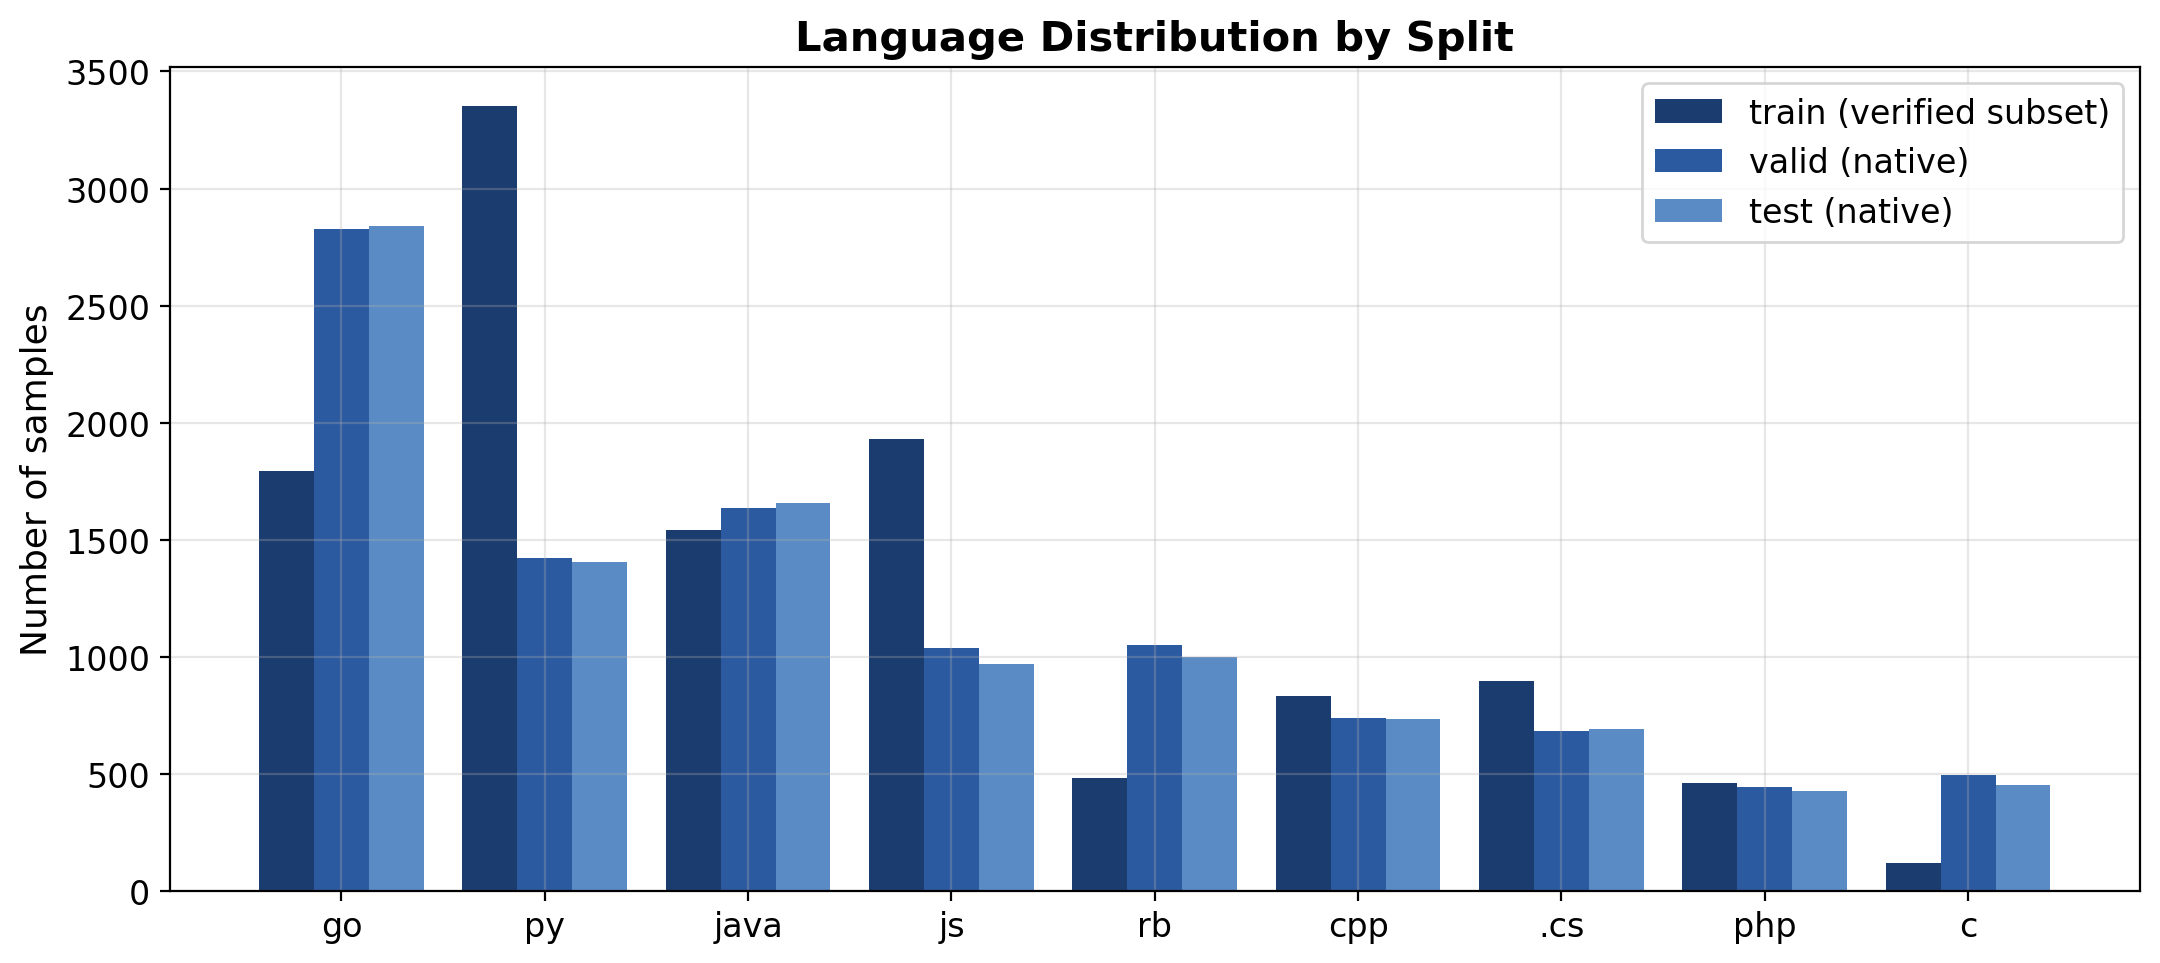

lang         train*    valid     test
--------------------------------------
  go          1,793    2,826    2,840
  py          3,353    1,420    1,403
  java        1,542    1,636    1,658
  js          1,929    1,035      967
  rb            483    1,049    1,000
  cpp           833      736      731
  .cs           896      682      691
  php           458      443      426
  c             118      492      453

* train = only verified subset (11,405 of 117,739 rows). Full train language mix is unknown - this is the data limitation.


In [ ]:
valid_langs = Counter(r['lang'] for r in valid if 'lang' in r)
test_langs  = Counter(r['lang'] for r in test  if 'lang' in r)
train_langs = Counter(r['lang_verified'] for r in train if r['lang_verified'])


all_langs = sorted(set(valid_langs) | set(test_langs) | set(train_langs),
                   key=lambda l: -(valid_langs[l]+test_langs[l]+train_langs[l]))

x = np.arange(len(all_langs))
w = 0.27

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w, [train_langs[l] for l in all_langs], w, label='train (verified subset)', color='#1a3c6e')
ax.bar(x,     [valid_langs[l] for l in all_langs], w, label='valid (native)',          color='#2c5aa0')
ax.bar(x + w, [test_langs[l]  for l in all_langs], w, label='test (native)',           color='#5a8bc4')

ax.set_xticks(x)
ax.set_xticklabels(all_langs)
ax.set_ylabel('Number of samples')
ax.set_title('Language Distribution by Split')
ax.legend()
plt.tight_layout()
fig.savefig('fig_language.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{'lang':8s} {'train*':>10s} {'valid':>8s} {'test':>8s}")
print("-"*38)
for l in all_langs:
    print(f"  {l:6s} {train_langs[l]:>10,} {valid_langs[l]:>8,} {test_langs[l]:>8,}")
print("\n* train = only verified subset (11,405 of 117,739 rows). "
      "Full train language mix is unknown - this is the data limitation.")

In [ ]:
%config InlineBackend.figure_format = 'retina'

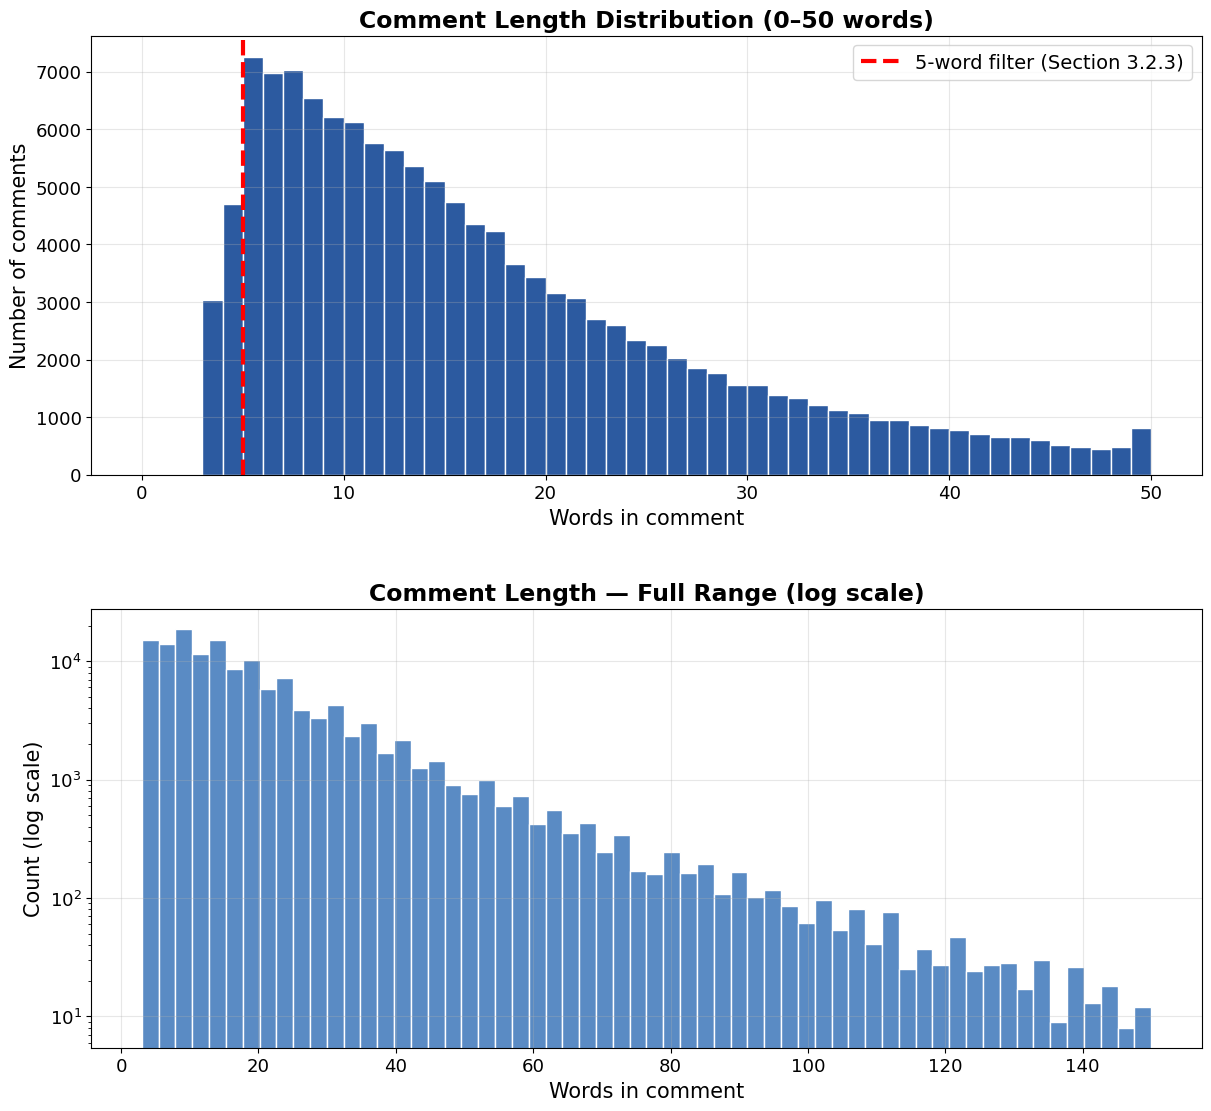

Comment length (words) — all splits combined:
  Total      : 138,227
  Mean       : 19.3   Median: 14
  Min / Max  : 3 / 150
  < 5 words  : 7,730  (5.6%)  ← 3.2.3 removes these


In [6]:


def word_count(text):
    return len(str(text).split())

all_wc = [word_count(r.get('msg','')) for r in (train + valid + test)]
arr = np.array(all_wc)

fig, axes = plt.subplots(2, 1, figsize=(13, 12))   


axes[0].hist(arr, bins=range(0, 51), color='#2c5aa0', edgecolor='white')
axes[0].axvline(5, color='red', linestyle='--', linewidth=3, label='5-word filter (Section 3.2.3)')
axes[0].set_xlabel('Words in comment', fontsize=15)
axes[0].set_ylabel('Number of comments', fontsize=15)
axes[0].set_title('Comment Length Distribution (0–50 words)', fontsize=17, fontweight='bold')
axes[0].legend(fontsize=14)
axes[0].tick_params(labelsize=13)


axes[1].hist(arr, bins=60, color='#5a8bc4', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_xlabel('Words in comment', fontsize=15)
axes[1].set_ylabel('Count (log scale)', fontsize=15)
axes[1].set_title('Comment Length — Full Range (log scale)', fontsize=17, fontweight='bold')
axes[1].tick_params(labelsize=13)

plt.tight_layout(pad=3)
fig.savefig('fig_comment_length.png', dpi=150, bbox_inches='tight')
plt.show()

print("Comment length (words) — all splits combined:")
print(f"  Total      : {len(arr):,}")
print(f"  Mean       : {arr.mean():.1f}   Median: {np.median(arr):.0f}")
print(f"  Min / Max  : {arr.min()} / {arr.max()}")
print(f"  < 5 words  : {(arr<5).sum():,}  ({(arr<5).mean()*100:.1f}%)  ← 3.2.3 removes these")

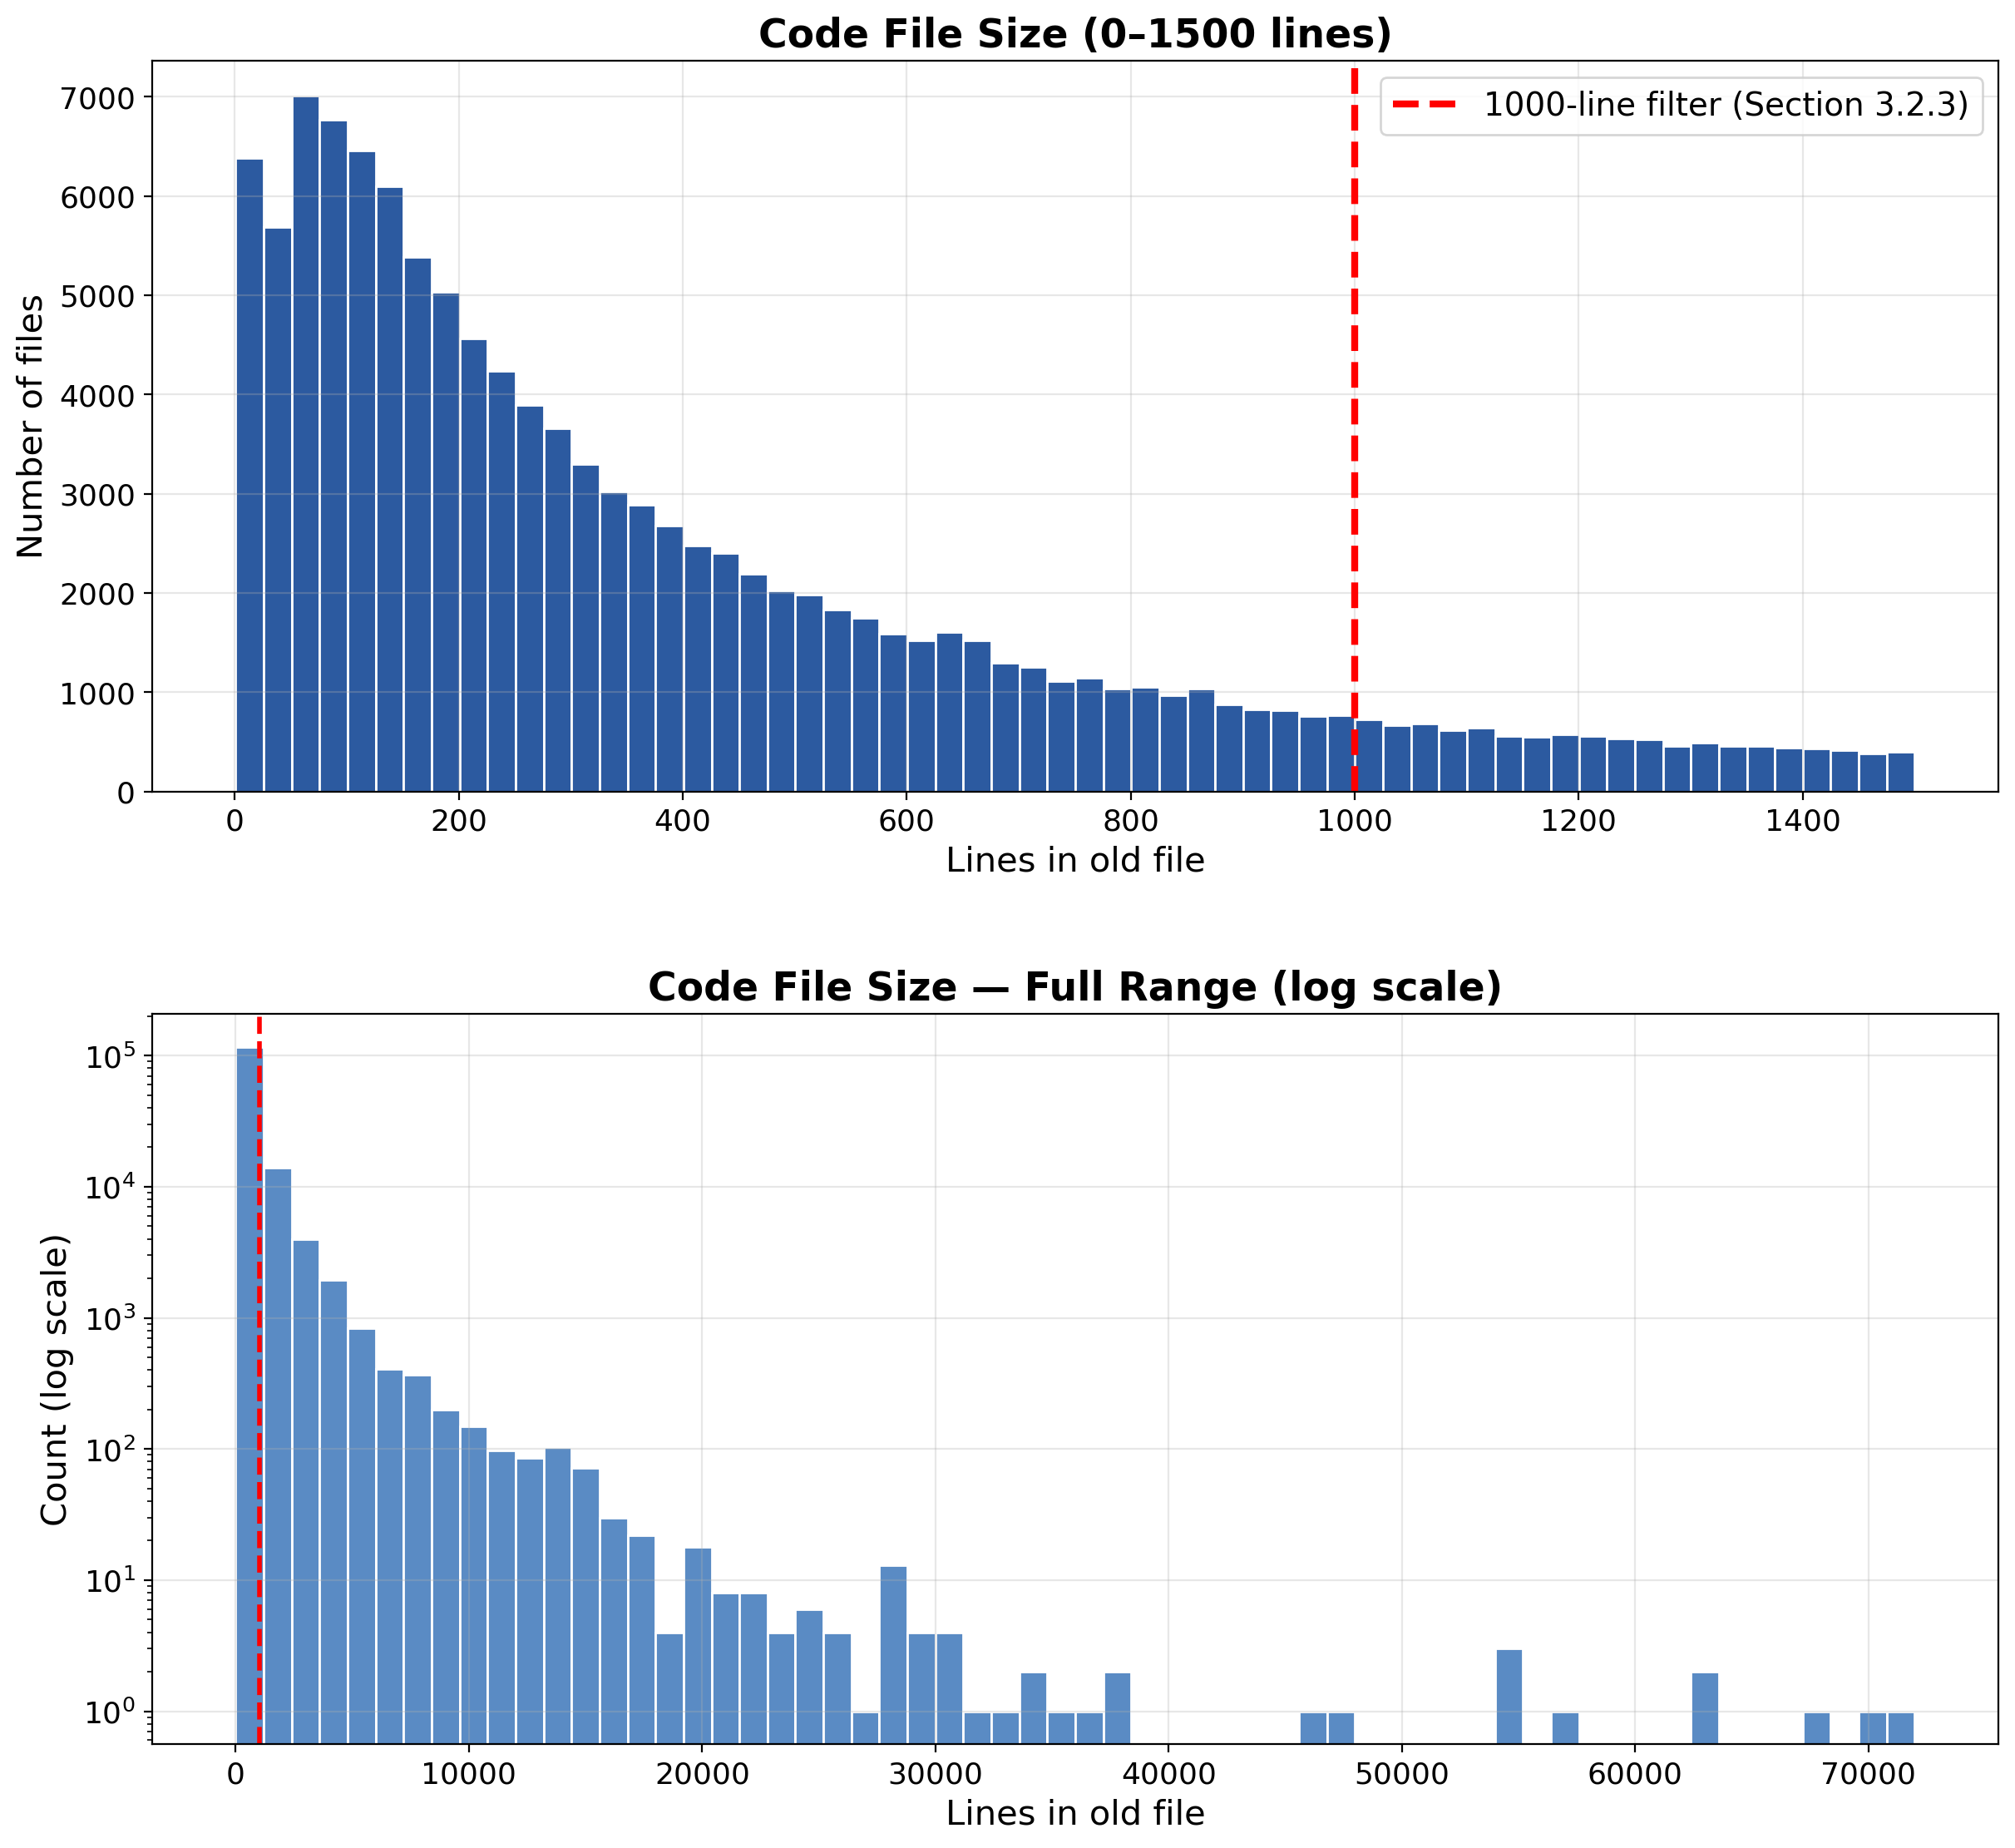

Code file size (lines) — all splits combined:
  Total      : 138,227
  Mean       : 755   Median: 331
  Min / Max  : 1 / 71,988
  25th/75th  : 135 / 797

  > 1000 lines : 27,320  (19.8%)  ← 3.2.3 removes these


In [25]:


def line_count(text):
    return str(text).count('\n') + 1

all_lines = [line_count(r.get('oldf','')) for r in (train + valid + test)]
arr = np.array(all_lines)

fig, axes = plt.subplots(2, 1, figsize=(13, 12))

axes[0].hist(arr[arr <= 1500], bins=60, color='#2c5aa0', edgecolor='white')
axes[0].axvline(1000, color='red', linestyle='--', linewidth=3, label='1000-line filter (Section 3.2.3)')
axes[0].set_xlabel('Lines in old file', fontsize=15)
axes[0].set_ylabel('Number of files', fontsize=15)
axes[0].set_title('Code File Size (0–1500 lines)', fontsize=17, fontweight='bold')
axes[0].legend(fontsize=14)
axes[0].tick_params(labelsize=13)


axes[1].hist(arr, bins=60, color='#5a8bc4', edgecolor='white')
axes[1].set_yscale('log')
axes[1].axvline(1000, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Lines in old file', fontsize=15)
axes[1].set_ylabel('Count (log scale)', fontsize=15)
axes[1].set_title('Code File Size — Full Range (log scale)', fontsize=17, fontweight='bold')
axes[1].tick_params(labelsize=13)

plt.tight_layout(pad=3)
fig.savefig('fig_code_size.png', dpi=150, bbox_inches='tight')
plt.show()

print("Code file size (lines) — all splits combined:")
print(f"  Total      : {len(arr):,}")
print(f"  Mean       : {arr.mean():.0f}   Median: {np.median(arr):.0f}")
print(f"  Min / Max  : {arr.min()} / {arr.max():,}")
print(f"  25th/75th  : {np.percentile(arr,25):.0f} / {np.percentile(arr,75):.0f}")
print(f"\n  > 1000 lines : {(arr>1000).sum():,}  ({(arr>1000).mean()*100:.1f}%)  ← 3.2.3 removes these")

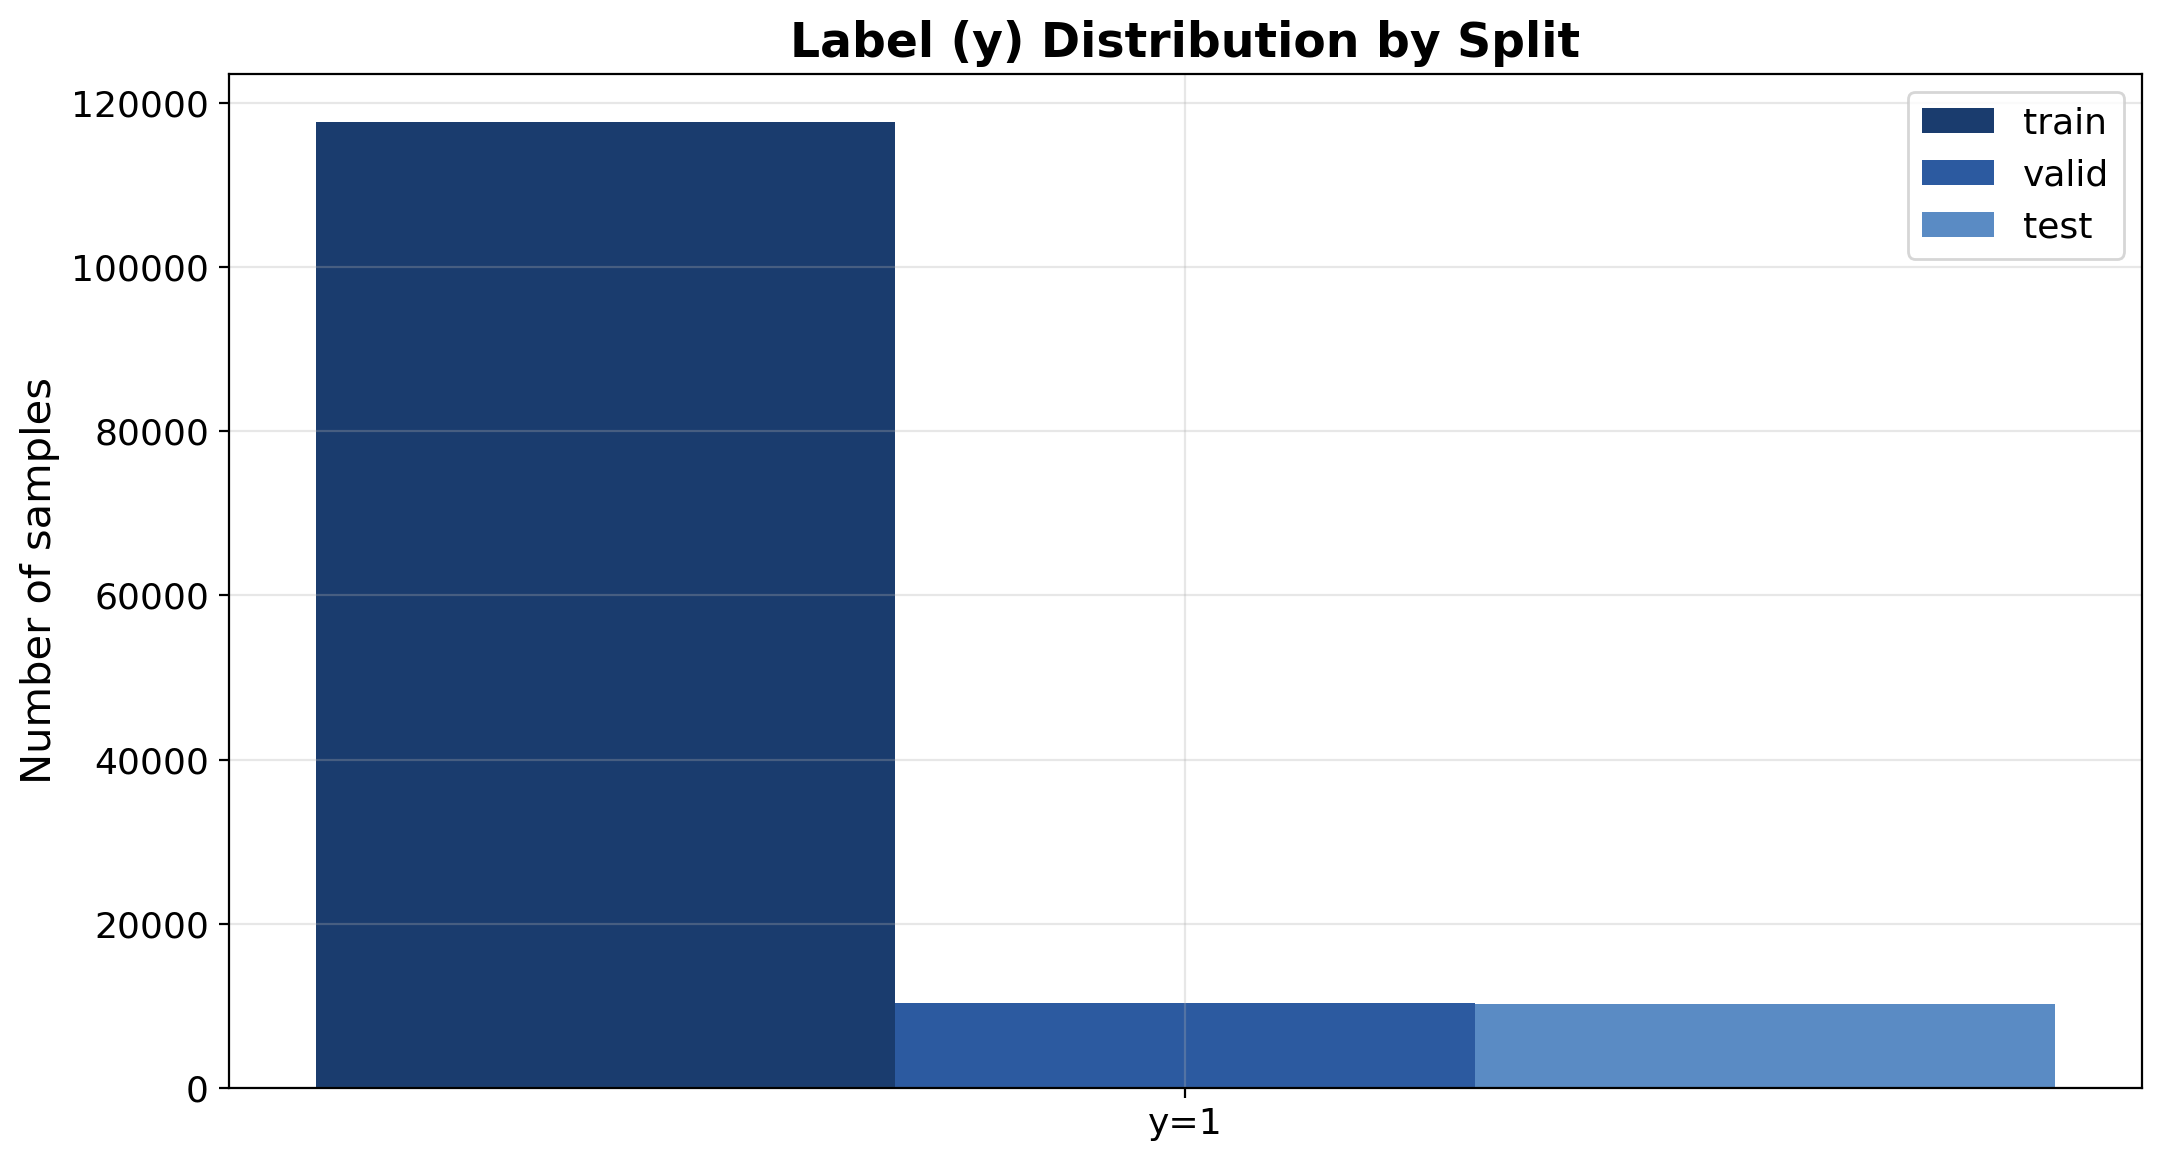

label         train    valid     test
--------------------------------------
  1         117,739   10,319   10,169


In [26]:


train_y = Counter(r.get('y') for r in train)
valid_y = Counter(r.get('y') for r in valid)
test_y  = Counter(r.get('y') for r in test)

labels = sorted(set(train_y) | set(valid_y) | set(test_y))
label_names = {0: 'y=0', 1: 'y=1'}  

x = np.arange(len(labels))
w = 0.27

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - w, [train_y[l] for l in labels], w, label='train', color='#1a3c6e')
ax.bar(x,     [valid_y[l] for l in labels], w, label='valid', color='#2c5aa0')
ax.bar(x + w, [test_y[l]  for l in labels], w, label='test',  color='#5a8bc4')

ax.set_xticks(x)
ax.set_xticklabels([label_names.get(l, str(l)) for l in labels])
ax.set_ylabel('Number of samples', fontsize=15)
ax.set_title('Label (y) Distribution by Split', fontsize=17, fontweight='bold')
ax.legend(fontsize=13)
ax.tick_params(labelsize=13)
plt.tight_layout()
fig.savefig('fig_repos.png', dpi=150, bbox_inches='tight')
plt.show()

# Table
print(f"{'label':8s} {'train':>10s} {'valid':>8s} {'test':>8s}")
print("-"*38)
for l in labels:
    print(f"  {str(l):6s} {train_y[l]:>10,} {valid_y[l]:>8,} {test_y[l]:>8,}")

Unique repositories:
  in valid : 217
  in test  : 212
  combined : 217

  Repos in BOTH valid & test : 212  (of 212 test repos)
  → Splits repository-disjoint? NO


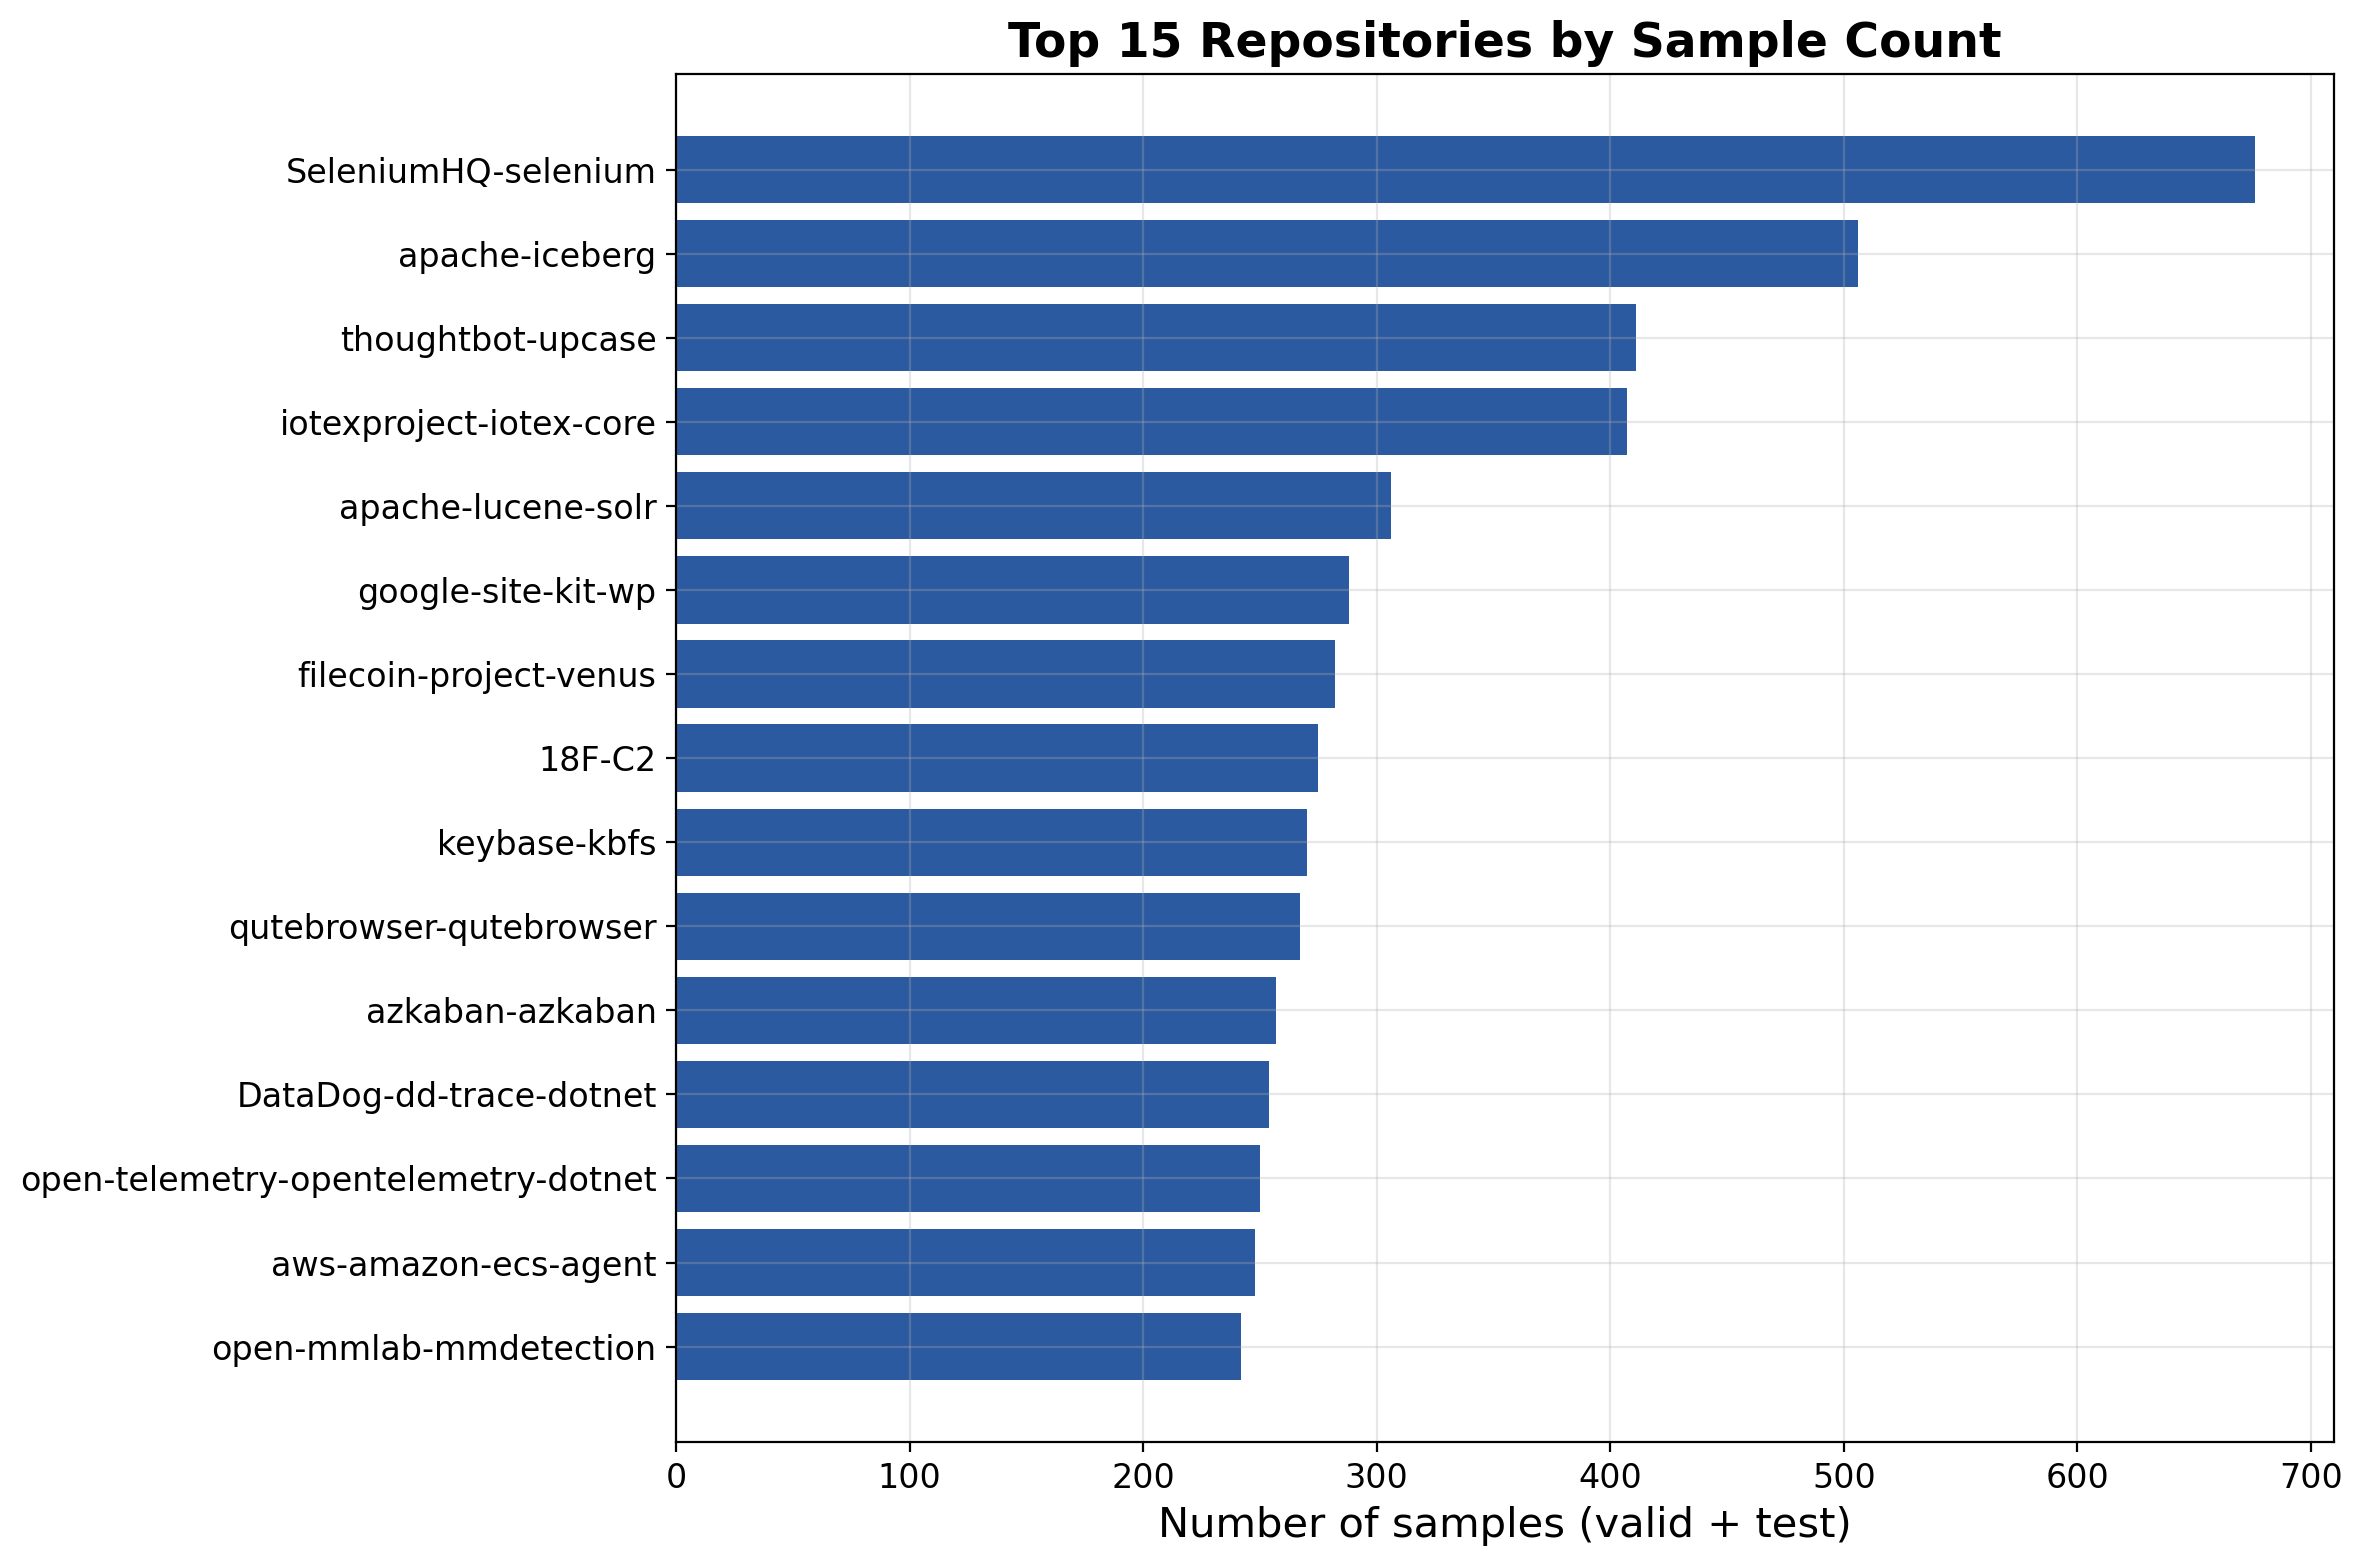

In [27]:

valid_repos = Counter(r['proj'] for r in valid if 'proj' in r)
test_repos  = Counter(r['proj'] for r in test  if 'proj' in r)
all_repos   = valid_repos + test_repos   # Counters add ho jaate hain

print(f"Unique repositories:")
print(f"  in valid : {len(valid_repos):,}")
print(f"  in test  : {len(test_repos):,}")
print(f"  combined : {len(all_repos):,}")

# Repo overlap (3.2.4 ke liye CRITICAL finding)
overlap = set(valid_repos) & set(test_repos)
print(f"\n  Repos in BOTH valid & test : {len(overlap):,}  (of {len(set(test_repos))} test repos)")
print(f"  → Splits repository-disjoint? {'NO' if overlap else 'YES'}")

# Top 15 repos by sample count
top = all_repos.most_common(15)
fig, ax = plt.subplots(figsize=(12, 8))
names = [r[0] for r in top][::-1]
counts = [r[1] for r in top][::-1]
ax.barh(names, counts, color='#2c5aa0')
ax.set_xlabel('Number of samples (valid + test)', fontsize=15)
ax.set_title('Top 15 Repositories by Sample Count', fontsize=17, fontweight='bold')
ax.tick_params(labelsize=12)
plt.tight_layout()
fig.savefig('fig_repos.png', dpi=150, bbox_inches='tight')
plt.show()

# CodeReviewer: Data Exploration (Comment Generation Task)

**Thesis:** Chain of Thought Supervision for Code Review Comment Generation
**Author:** Ayush Srivastava (24268798) MSc AI, NCI

This notebook performs **exploratory analysis only** on the CodeReviewer dataset (no filtering applied yet). Filtering approach to be decided after supervisor discussion.

## Key Findings

| Aspect | Finding |
|---|---|
| **Dataset size** | train 117,739 · valid 10,319 · test 10,169 (total 138,227) |
| **Missing metadata** | `msg-train` has **no `lang` or `proj`** fields; only valid/test have them |
| **Verified Python** | train 3,353 · valid 1,420 · test 1,403 = **6,176** (zero-noise, content-matched) |
| **Label (`y`)** | All samples `y=1` (comment present by construction) — no signal for generation |
| **Comment length** | **5.6%** of comments under 5 words (relevant to Section 3.2.3 filter) |
| **Code size** | **19.8%** of files over 1000 lines (relevant to Section 3.2.3 filter) |
| **Repository overlap** | **212 of 212 test repos also appear in validation → splits are NOT repository-disjoint** |

## Important Note on Splits
The official CodeReviewer splits are **not repository-disjoint** the same repositories appear across train/valid/test. This is the kind of leakage warned about in the proposal (Section 3.2.4) and by Liu et al. (2018). To be documented as a finding/limitation.

---

In [19]:
short_pct = (np.array(all_wc) < 5).mean() * 100
large_pct = (np.array(all_lines) > 1000).mean() * 100
print(f"short_pct={short_pct:.2f}")
print(f"large_pct={large_pct:.2f}")

short_pct=5.59
large_pct=19.76
